## Shibuya Calibration Process Flow Notebook

This notebook converts the Shibuya calibration process plan into a runnable workflow. It is separate from `Shibuya_Calibration.ipynb`, so we can test homography and point mapping without disturbing the main calibration notebook.

The main goal here is simple:

1. load one clear reference frame from the Shibuya video,
2. choose four or more points on the road/crosswalk plane,
3. assign real-world metre coordinates to those same points,
4. compute the homography matrix,
5. test whether pixel points can be mapped into world coordinates correctly.

This notebook is especially useful for debugging the most fragile part of the pipeline: converting pixels into metres.

### 1. Why This Notebook?

The Shibuya video is not being used as an emergency dataset. It is used as a normal dense-crowd movement calibration case.

Before running SFM calibration, we need reliable real-world measurements. Video coordinates are in pixels, but SFM requires distances in metres. Homography gives us a mapping between the image plane and the road plane.

The key condition is:

> The selected calibration points must all lie on the same physical plane.

For Shibuya, that means points on the road/crosswalk surface only. Do not use building corners, signboards, traffic lights, elevated structures, kerbs with height change, or pedestrians.

### 2. Process Flow

```mermaid
flowchart TD
    A[Choose reference video/frame] --> B[Pick road-plane image points]
    B --> C[Measure or estimate real-world coordinates]
    C --> D[Compute homography matrix]
    D --> E[Map pixel points into metres]
    E --> F[Validate with known distances]
    F --> G[Use mapping for pedestrian tracks]
    G --> H[Compute speed, direction, flow, density, spacing]
    H --> I[Calibrate SFM baseline]
```

### 3. Setup

This cell defines folder paths and imports libraries. OpenCV is preferred for homography, but the notebook will still help you prepare point tables even if OpenCV is not installed yet.

In [1]:
from pathlib import Path
import json
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import cv2
    OPENCV_AVAILABLE = True
except ImportError:
    OPENCV_AVAILABLE = False
    print("OpenCV is not installed. Homography computation needs: pip install opencv-python")

NOTEBOOK_DIR = Path.cwd()
DATA_DIR = NOTEBOOK_DIR / "data" / "shibuya"
VIDEO_DIR = DATA_DIR / "videos"
FRAME_DIR = DATA_DIR / "frames"
OUTPUT_DIR = DATA_DIR / "outputs"
POINTS_DIR = DATA_DIR / "homography_points"

for folder in [VIDEO_DIR, FRAME_DIR, OUTPUT_DIR, POINTS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Notebook dir:", NOTEBOOK_DIR)
print("Frame dir:", FRAME_DIR)
print("Point-table dir:", POINTS_DIR)

Notebook dir: c:\Users\kylet\HTX\Deliverable 1\Documentation\Task 1 - NTU Paper + GABM
Frame dir: c:\Users\kylet\HTX\Deliverable 1\Documentation\Task 1 - NTU Paper + GABM\data\shibuya\frames
Point-table dir: c:\Users\kylet\HTX\Deliverable 1\Documentation\Task 1 - NTU Paper + GABM\data\shibuya\homography_points


### 4. Recommended Video / Frame Choice

Use the 2019 Wikimedia video as the primary source because it is higher resolution and more suitable for point selection.

Recommended pilot settings:

| Item | Recommendation |
|---|---|
| Source video | `shibuya_2019_crossing.webm` |
| Analysis duration | 10 to 15 seconds |
| Frame sampling | 2 to 5 FPS |
| Reference frame | One clear frame with visible crosswalk/road markings |
| Calibration points | At least 4, preferably 6 to 8 |
| Point locations | Road/crosswalk plane only |

If the exact road dimensions are unclear, use map/aerial measurement as a first estimate and ask permstaff/domain staff to verify the geometry later.

### 5. Load A Reference Frame

Set `REFERENCE_FRAME_PATH` to a clear extracted frame. If you already extracted frames in `Shibuya_Calibration.ipynb`, point this to one of those `.jpg` files.

If you do not have a frame yet, run the optional video extraction cell below after installing OpenCV.

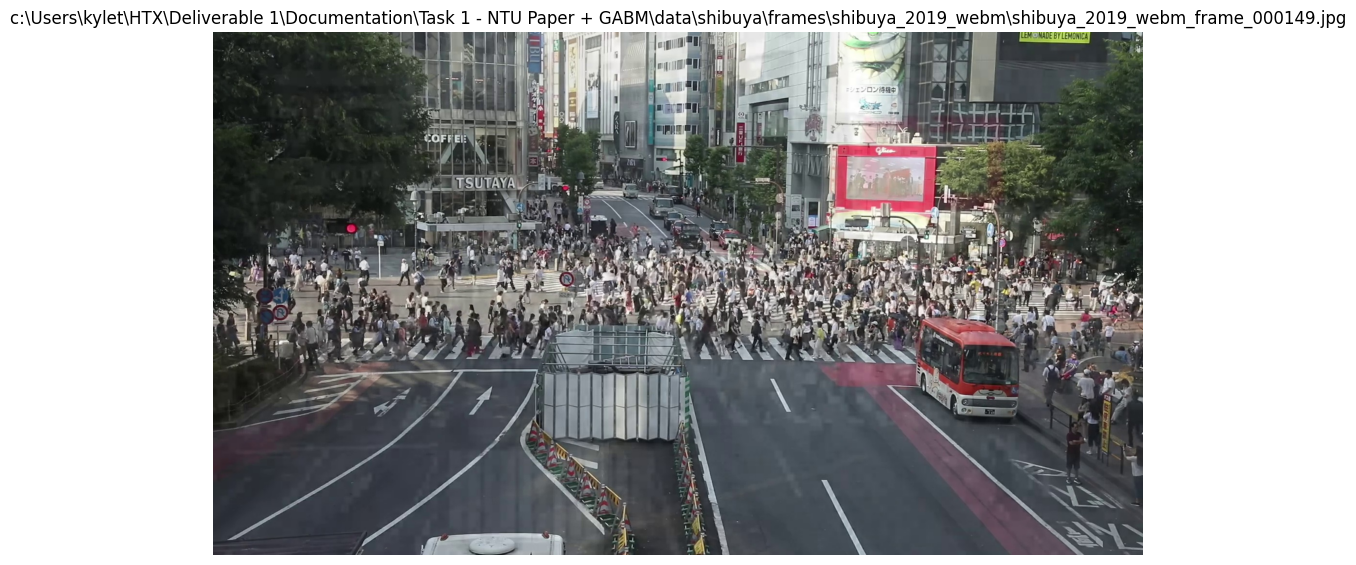

In [2]:
# Option A: point this to an existing extracted frame.
# Example:
# REFERENCE_FRAME_PATH = FRAME_DIR / "shibuya_2019_webm" / "shibuya_2019_webm_frame_000150.jpg"

REFERENCE_FRAME_PATH = FRAME_DIR / "shibuya_2019_webm" / "shibuya_2019_webm_frame_000149.jpg"

def load_image_rgb(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(path)

    if OPENCV_AVAILABLE:
        img_bgr = cv2.imread(str(path))
        if img_bgr is None:
            raise ValueError(f"Could not read image: {path}")
        return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    from PIL import Image
    return np.asarray(Image.open(path).convert("RGB"))


if REFERENCE_FRAME_PATH is None:
    print("Set REFERENCE_FRAME_PATH to an extracted frame before plotting.")
else:
    reference_img = load_image_rgb(REFERENCE_FRAME_PATH)
    plt.figure(figsize=(12, 7))
    plt.imshow(reference_img)
    plt.title(str(REFERENCE_FRAME_PATH))
    plt.axis("off")
    plt.show()

### 6. Optional: Extract One Reference Frame From Video

Use this only if you have the video but no extracted frames yet.

This cell extracts a single frame at `REFERENCE_TIME_S`. Choose a time where road/crosswalk markings are visible and not too blocked by pedestrians.

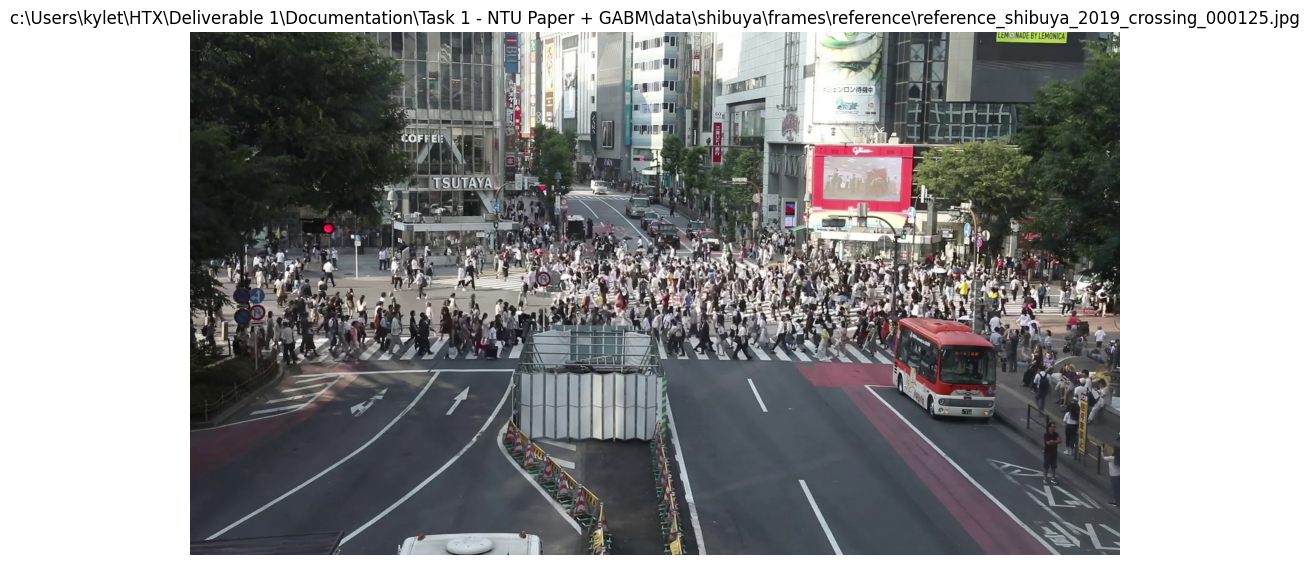

In [3]:
VIDEO_PATH = VIDEO_DIR / "shibuya_2019_crossing.webm"
REFERENCE_TIME_S = 5.0


def extract_reference_frame(video_path, time_s, out_dir=FRAME_DIR / "reference"):
    if not OPENCV_AVAILABLE:
        raise ImportError("OpenCV is required to extract frames from video. Install with: pip install opencv-python")

    video_path = Path(video_path)
    if not video_path.exists():
        raise FileNotFoundError(f"Video not found: {video_path}")

    out_dir.mkdir(parents=True, exist_ok=True)
    cap = cv2.VideoCapture(str(video_path))
    fps = cap.get(cv2.CAP_PROP_FPS)
    if not fps or fps <= 0:
        fps = 30

    frame_idx = int(time_s * fps)
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
    ok, frame = cap.read()
    cap.release()

    if not ok:
        raise RuntimeError(f"Could not extract frame at {time_s}s")

    out_path = out_dir / f"reference_{video_path.stem}_{frame_idx:06d}.jpg"
    cv2.imwrite(str(out_path), frame)
    return out_path


# Uncomment after VIDEO_PATH exists locally.
REFERENCE_FRAME_PATH = extract_reference_frame(VIDEO_PATH, REFERENCE_TIME_S)
reference_img = load_image_rgb(REFERENCE_FRAME_PATH)
plt.figure(figsize=(12, 7))
plt.imshow(reference_img)
plt.title(str(REFERENCE_FRAME_PATH))
plt.axis("off")
plt.show()

### 7. Select Image Points

There are two ways to select points:

| Method | When to use |
|---|---|
| Manual table | Most reliable inside VS Code/Jupyter. Read pixel coordinates from an image viewer or annotation tool and type them into a table. |
| Click-based selection | Convenient, but can be unreliable depending on notebook backend. Use only if interactive Matplotlib works. |

For the pilot, manual table entry is safer.

Important: point ordering must match between `image_points_px` and `world_points_m`. If image point 1 is the near-left crosswalk corner, world point 1 must be the same physical corner.

In [4]:
# Fill this table with points from the selected reference image.
# All image points must be on the road/crosswalk plane.

point_table = pd.DataFrame([
    # point_id, x_px, y_px, x_m, y_m, notes
    # ["P1", 0, 0, 0.0, 0.0, "example only"],
    # ["P2", 100, 0, 10.0, 0.0, "example only"],
    # ["P3", 100, 80, 10.0, 8.0, "example only"],
    # ["P4", 0, 80, 0.0, 8.0, "example only"],
], columns=["point_id", "x_px", "y_px", "x_m", "y_m", "notes"])

point_table

,point_id,x_px,y_px,x_m,y_m,notes


### 7.1 Click-Based Image Point Selection

This cell lets you click calibration points directly on the reference frame.

Instructions:

1. Run `%matplotlib widget` first if your VS Code/Jupyter environment supports it.
2. Run the click-selection cell.
3. Click at least 4 road-plane points on the image.
4. Press `Enter` when finished.
5. The clicked pixel coordinates will be stored in `clicked_points_df`.

Important: click points on the road/crosswalk plane only. These points must later be matched to real-world metre coordinates before homography can be computed.

In [ ]:
# Try this if the plot does not accept clicks in VS Code/Jupyter.
# If it errors, use `%matplotlib inline` and the manual point table instead.

try:
    get_ipython().run_line_magic("matplotlib", "widget")
    print("Interactive Matplotlib widget mode enabled.")
except Exception as e:
    print("Could not enable widget mode:", e)
    print("Fallback: use manual table entry or try `%matplotlib notebook`.")

In [ ]:
def click_image_points(image, n_points=8, timeout=0):
    """
    Click up to n_points on the image.

    Controls:
    - left click: add point
    - Enter: finish early

    Returns a DataFrame with point_id, x_px, y_px.
    """
    fig, ax = plt.subplots(figsize=(12, 7))
    ax.imshow(image)
    ax.set_title(f"Click up to {n_points} road-plane points, then press Enter")
    ax.axis("off")

    pts = plt.ginput(n=n_points, timeout=timeout)
    plt.close(fig)

    clicked = pd.DataFrame(
        [[f"P{i+1}", float(x), float(y), np.nan, np.nan, "clicked road-plane point"] for i, (x, y) in enumerate(pts)],
        columns=["point_id", "x_px", "y_px", "x_m", "y_m", "notes"]
    )
    return clicked


if "reference_img" not in globals():
    print("Load a reference image first by running Section 5.")
else:
    clicked_points_df = click_image_points(reference_img, n_points=8, timeout=0)
    display(clicked_points_df)

### 7.2 Add Real-World Coordinates To Clicked Points

After clicking the image points, fill in the corresponding real-world coordinates in metres.

The image and world point order must match. For example, if `P1` is the near-left crosswalk corner in the image, then `P1` must also be the near-left crosswalk corner in metre coordinates.

If exact Shibuya dimensions are not available yet, enter estimated map/aerial measurements and mark the `notes` column clearly as an estimate.

In [ ]:
# Start from clicked points if available; otherwise keep the existing manual point_table.
if "clicked_points_df" in globals() and not clicked_points_df.empty:
    point_table = clicked_points_df.copy()
else:
    print("No clicked points found yet. Keeping existing point_table.")

# Fill x_m and y_m manually after measuring/estimating the same points in real-world metres.
# Example only:
# point_table.loc[point_table["point_id"] == "P1", ["x_m", "y_m"]] = [0.0, 0.0]
# point_table.loc[point_table["point_id"] == "P2", ["x_m", "y_m"]] = [10.0, 0.0]
# point_table.loc[point_table["point_id"] == "P3", ["x_m", "y_m"]] = [10.0, 8.0]
# point_table.loc[point_table["point_id"] == "P4", ["x_m", "y_m"]] = [0.0, 8.0]

point_table

### 8. Save / Load Point Tables

Save calibration points separately so they can be reviewed, corrected, and reused.

Recommended filename format:

`shibuya_2019_reference_homography_points.csv`

In [5]:
POINT_TABLE_PATH = POINTS_DIR / "shibuya_2019_reference_homography_points.csv"


def save_point_table(point_table, path=POINT_TABLE_PATH):
    point_table.to_csv(path, index=False)
    print("Saved:", path)


def load_point_table(path=POINT_TABLE_PATH):
    path = Path(path)
    if not path.exists():
        print("Point table not found yet:", path)
        return pd.DataFrame(columns=["point_id", "x_px", "y_px", "x_m", "y_m", "notes"])
    return pd.read_csv(path)


# Uncomment after filling point_table.
save_point_table(point_table)

loaded_point_table = load_point_table()
loaded_point_table

Saved: c:\Users\kylet\HTX\Deliverable 1\Documentation\Task 1 - NTU Paper + GABM\data\shibuya\homography_points\shibuya_2019_reference_homography_points.csv


,point_id,x_px,y_px,x_m,y_m,notes


### 9. Visualise Selected Image Points

This helps debug whether the selected points are actually on the road plane and ordered correctly.

In [6]:
def plot_image_points(image, points_df, label_col="point_id"):
    if points_df.empty:
        print("No points to plot yet.")
        return

    fig, ax = plt.subplots(figsize=(12, 7))
    ax.imshow(image)
    ax.scatter(points_df["x_px"], points_df["y_px"], s=80, c="red")

    for _, row in points_df.iterrows():
        ax.text(row["x_px"] + 8, row["y_px"] + 8, str(row[label_col]), color="yellow", fontsize=12, weight="bold")

    ax.set_title("Selected homography points on reference frame")
    ax.axis("off")
    plt.show()


# Use loaded_point_table if you saved points, otherwise point_table.
points_for_plot = loaded_point_table if not loaded_point_table.empty else point_table

if REFERENCE_FRAME_PATH is None:
    print("Set REFERENCE_FRAME_PATH and load reference_img before plotting points.")
else:
    plot_image_points(reference_img, points_for_plot)

No points to plot yet.


### 10. Compute Homography

This cell computes the matrix that maps image pixel coordinates to real-world metre coordinates.

The algorithm solves:

`[x_px, y_px] -> [x_m, y_m]`

Use at least 4 points. More than 4 points is better if the point measurements are consistent.

In [7]:
def validate_point_table(points_df):
    required = ["x_px", "y_px", "x_m", "y_m"]
    missing = [col for col in required if col not in points_df.columns]
    if missing:
        raise ValueError(f"Missing columns: {missing}")

    clean = points_df.dropna(subset=required).copy()
    if len(clean) < 4:
        raise ValueError("Need at least 4 complete point rows to compute homography.")

    return clean


def compute_homography_from_table(points_df):
    if not OPENCV_AVAILABLE:
        raise ImportError("OpenCV is required for homography. Install with: pip install opencv-python")

    clean = validate_point_table(points_df)
    image_points = clean[["x_px", "y_px"]].to_numpy(dtype=np.float32)
    world_points = clean[["x_m", "y_m"]].to_numpy(dtype=np.float32)

    H, status = cv2.findHomography(image_points, world_points, method=0)
    if H is None:
        raise RuntimeError("Homography computation failed. Recheck point ordering and whether all points are coplanar.")

    return H, status, clean


points_for_h = loaded_point_table if not loaded_point_table.empty else point_table

try:
    H_img_to_world, h_status, h_points = compute_homography_from_table(points_for_h)
    print("Homography image -> world:")
    print(H_img_to_world)
    display(h_points)
except Exception as e:
    H_img_to_world = None
    h_points = pd.DataFrame()
    print("Homography not ready:", e)

Homography not ready: Need at least 4 complete point rows to compute homography.


### 11. Test Point Mapping

After computing homography, map the calibration image points back into world coordinates. The predicted world coordinates should be close to the manually entered world coordinates.

Large errors usually mean:

- point ordering mismatch,
- one or more points are not on the road plane,
- real-world distances are inaccurate,
- pixel coordinates are wrong.

In [8]:
def pixels_to_world(points_px, H):
    points_px = np.asarray(points_px, dtype=np.float32).reshape(-1, 1, 2)
    points_m = cv2.perspectiveTransform(points_px, H)
    return points_m.reshape(-1, 2)


def homography_residual_report(points_df, H):
    clean = validate_point_table(points_df)
    pred = pixels_to_world(clean[["x_px", "y_px"]].to_numpy(), H)

    report = clean.copy()
    report["pred_x_m"] = pred[:, 0]
    report["pred_y_m"] = pred[:, 1]
    report["error_m"] = np.sqrt((report["pred_x_m"] - report["x_m"])**2 + (report["pred_y_m"] - report["y_m"])**2)
    return report


if H_img_to_world is None:
    print("Compute homography first.")
else:
    residual_report = homography_residual_report(points_for_h, H_img_to_world)
    display(residual_report)
    print("Mean residual error (m):", residual_report["error_m"].mean())
    print("Max residual error (m):", residual_report["error_m"].max())

Compute homography first.


### 12. Plot Mapped World Points

This plot shows the real-world layout implied by the point table. It is a quick check for whether the world coordinates make geometric sense.

In [9]:
def plot_world_points(points_df):
    if points_df.empty:
        print("No world points to plot yet.")
        return

    clean = points_df.dropna(subset=["x_m", "y_m"])
    if clean.empty:
        print("No complete x_m/y_m values yet.")
        return

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.scatter(clean["x_m"], clean["y_m"], s=90)
    for _, row in clean.iterrows():
        ax.text(row["x_m"] + 0.2, row["y_m"] + 0.2, str(row["point_id"]), fontsize=12)
    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
    ax.set_title("World-coordinate calibration points")
    ax.axis("equal")
    ax.grid(alpha=0.3)
    plt.show()


plot_world_points(points_for_h)

No world points to plot yet.


### 13. Map New Pixel Points

Once homography is ready, use this cell to convert any new image pixel coordinate into real-world metres.

This is how pedestrian annotations will eventually become real trajectories.

In [10]:
# Add any pixel points you want to test here.
test_pixels = pd.DataFrame([
    # ["T1", 500, 600],
    # ["T2", 700, 620],
], columns=["point_id", "x_px", "y_px"])

if H_img_to_world is None:
    print("Compute homography first.")
elif test_pixels.empty:
    print("Add rows to test_pixels to map new image points.")
else:
    mapped = pixels_to_world(test_pixels[["x_px", "y_px"]].to_numpy(), H_img_to_world)
    mapped_df = test_pixels.copy()
    mapped_df["x_m"] = mapped[:, 0]
    mapped_df["y_m"] = mapped[:, 1]
    display(mapped_df)

Compute homography first.


### 14. Distance and Direction Between Points

SFM calibration needs distances and directions between positions. This cell computes distance and direction between two mapped world points.

Direction is reported in degrees using:

`atan2(dy, dx)`

In [11]:
def distance_and_direction(p1, p2):
    p1 = np.asarray(p1, dtype=float)
    p2 = np.asarray(p2, dtype=float)
    d = p2 - p1
    distance_m = float(np.sqrt((d ** 2).sum()))
    direction_deg = float(np.degrees(np.arctan2(d[1], d[0])))
    return distance_m, direction_deg


# Example after mapping two points:
# distance_m, direction_deg = distance_and_direction([0, 0], [3, 4])
# print(distance_m, direction_deg)

### 15. Debug Checklist

| Problem | Likely cause | Fix |
|---|---|---|
| Speeds are unrealistically high | Homography scale wrong, points not on same plane, FPS wrong | Recheck point coordinates, road-plane requirement, and video metadata. |
| Mapped world points look flipped | Image/world point ordering mismatch | Ensure P1 in image corresponds to P1 in world table. |
| Homography fails | Fewer than 4 complete points or duplicated points | Add at least 4 distinct road-plane points. |
| Residual error is large | Inaccurate world dimensions or bad pixel clicks | Re-measure map distances and choose clearer points. |
| Pedestrian tracks curve weirdly | Wrong homography or using non-ground point such as head instead of footpoint | Annotate consistent footpoint/ground contact positions. |
| Processing too slow | Video too large or too many frames | Use 10-15 seconds, 2-5 FPS, and downscale to 720p. |

If dimensions are uncertain, ask permstaff/domain staff for approximate crossing geometry before treating the measured speeds as final.

### 16. How This Feeds SFM Calibration

After homography works, the next step is to apply the same mapping to pedestrian tracks.

For each pedestrian:

1. annotate or detect pixel location over time,
2. map each pixel location to metres,
3. compute step distance and direction,
4. compute speed as distance divided by time,
5. aggregate speed distribution, direction groups, density, flow, and spacing,
6. tune SFM parameters until simulated movement roughly matches observed movement.

This makes the later emergency evacuation simulations more defensible because the baseline movement model is grounded in real crowd footage.

### 17. References

- Wikimedia Commons: [Shibuya Crossing, Tokyo, Japan (video).webm](https://commons.wikimedia.org/wiki/File:Shibuya_Crossing,_Tokyo,_Japan_(video).webm)
- Wikimedia Commons: [Shibuya Scramble Crossing.ogv](https://commons.wikimedia.org/wiki/File:Shibuya_Scramble_Crossing.ogv)
- Wikimedia Commons: [Shibuya Crossing, Aerial.jpg](https://commons.wikimedia.org/wiki/File:Shibuya_Crossing,_Aerial.jpg)
- Guinness World Records: [Busiest pedestrian crossing](https://www.guinnessworldrecords.com/world-records/448095-busiest-pedestrian-crossing)
- Wikipedia: [Shibuya Crossing](https://en.wikipedia.org/wiki/Shibuya_Crossing)